## Fine-tuned multiGradICON: CT-US registration demo

This notebook runs inference with a **local fine-tuned multiGradICON checkpoint** on your CT and US volumes. Registration direction: **CT (moving) -> US (fixed)**, i.e. align CT to US.

It supports two modes:
1. Skip init transform (default, for CT already aligned/resampled in US space).
2. Apply explicit CT->US initialization transform (`.tfm`) when needed.

After that, it runs deformable instance optimization for per-case refinement.

### Imports

In [8]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import itk
import matplotlib.pyplot as plt
import icon_registration.itk_wrapper as itk_wrapper
from unigradicon import get_multigradicon, make_sim, preprocess

### Paths and constants

In [9]:
# Fine-tuned multiGradICON checkpoint (required).
TEST_DATA_DIR = r"C:\Users\gabridal\Documents\TRUSTED_reg\test"
CASE_ID = "206L"  # Change this to another case id (e.g. 206L, 371R, 641R)

CT_DATA_DIR = os.path.join(TEST_DATA_DIR, "CT_DATA")
US_DATA_DIR = os.path.join(TEST_DATA_DIR, "US_DATA")
WEIGHTS_DIR = os.path.join(TEST_DATA_DIR, "weights_mind")

CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "network_weights_final.trch")

# Registration: CT (moving) -> US (fixed).
PATH_MOVING_CT = os.path.join(CT_DATA_DIR, "CT_images", f"{CASE_ID}_imgCT.nii.gz")
PATH_FIXED_US = os.path.join(US_DATA_DIR, "US_images", f"{CASE_ID}_imgUS.nii.gz")

# Required segmentations for Dice-guided optimization.
# TRUSTED layout uses CT masks in CT_DATA/CT_masks and US masks in US_DATA/US_masks.
PATH_SEG_MOVING_CT = os.path.join(CT_DATA_DIR, "CT_masks", f"{CASE_ID}_seg.nii.gz")
PATH_SEG_FIXED_US = os.path.join(US_DATA_DIR, "US_masks", f"{CASE_ID}_maskUS.nii.gz")

# Optional CT->US initialization transform.
# Default False: use this when CT is already resampled/aligned in US space.
USE_INIT_TRANSFORM = False
TRANSFORM_DIR = os.path.join(CT_DATA_DIR, "rigid_transforms")
PATH_INIT_TRANSFORM = os.path.join(TRANSFORM_DIR, f"{CASE_ID}_CT_to_US_pca_icp.tfm")

required_paths = [
    CHECKPOINT_PATH,
    PATH_MOVING_CT,
    PATH_FIXED_US,
    PATH_SEG_MOVING_CT,
    PATH_SEG_FIXED_US,
]
if USE_INIT_TRANSFORM:
    required_paths.append(PATH_INIT_TRANSFORM)

for p in required_paths:
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing required file: {p}")

INPUT_SHAPE = (175, 175, 175)
CT_WINDOW = (-1000, 1000)
US_QUANTILE_RANGE = (0.0, 0.99)
IO_ITERATIONS = 10
IO_LR = 2e-5
DICE_LOSS_WEIGHT = 0.1

# Loss configuration for inference-time instance optimization.
SIMILARITY = "mind"  # Options: "lncc", "lncc2", "mind"
MIND_RADIUS = 2
MIND_DILATION = 2

# Set to False to run only PRIMARY_SETUP.
RUN_COMPARISON = False
PRIMARY_SETUP = ("mind_with_dice", SIMILARITY, DICE_LOSS_WEIGHT)
COMPARE_SETUPS = [
    ("lncc_no_dice", "lncc", 0.0),
    ("mind_with_dice", "mind", DICE_LOSS_WEIGHT),
]

### Load and inspect images

In [10]:
# Reorient to RAS for consistency with finetuning preprocessing.
def reorient_to_ras(img):
    orienter = itk.OrientImageFilter.New(Input=img)
    orienter.UseImageDirectionOn()

    # ITK Python bindings differ by version: some expect an AnatomicalOrientation
    # object, while others accept the SpatialOrientation enum directly.
    try:
        ras_code = itk.SpatialOrientationEnums.ValidCoordinateOrientations_ITK_COORDINATE_ORIENTATION_RAS
        try:
            orienter.SetDesiredCoordinateOrientation(itk.AnatomicalOrientation(ras_code))
        except Exception:
            orienter.SetDesiredCoordinateOrientation(ras_code)
        orienter.Update()
        return orienter.GetOutput()
    except Exception as exc:
        print(f"Warning: could not reorient to RAS ({exc}). Continuing with original orientation.")
        return img

def load_volume(path, cast_segmentation=False):
    img = itk.imread(path)
    img = reorient_to_ras(img)
    if cast_segmentation:
        img = itk.CastImageFilter[type(img), itk.Image[itk.SS, 3]].New()(img)
    arr = np.asarray(img)
    spacing = tuple(float(s) for s in img.GetSpacing())
    return img, arr, spacing

def apply_init_transform(moving_img, moving_seg_img, fixed_img, transform_path):
    transforms = itk.transformread(transform_path)
    if not transforms:
        raise RuntimeError(f"No transforms found in {transform_path}")
    tx_ct_to_us = transforms[0]

    # For output-on-US-grid resampling, use output->input mapping.
    # A CT->US transform therefore needs inversion for ResampleImageFilter.
    try:
        tx_for_resample = tx_ct_to_us.GetInverseTransform()
    except Exception:
        tx_for_resample = tx_ct_to_us.GetInverse()

    moved_img = itk.resample_image_filter(
        moving_img,
        transform=tx_for_resample,
        interpolator=itk.LinearInterpolateImageFunction.New(moving_img),
        use_reference_image=True,
        reference_image=fixed_img,
    )
    moved_seg = itk.resample_image_filter(
        moving_seg_img,
        transform=tx_for_resample,
        interpolator=itk.NearestNeighborInterpolateImageFunction.New(moving_seg_img),
        use_reference_image=True,
        reference_image=fixed_img,
    )
    moved_seg = itk.CastImageFilter[type(moved_seg), itk.Image[itk.SS, 3]].New()(moved_seg)
    return moved_img, moved_seg

moving_ct_img, moving_ct_arr, moving_ct_spacing = load_volume(PATH_MOVING_CT)
fixed_us_img, fixed_us_arr, fixed_us_spacing = load_volume(PATH_FIXED_US)
moving_ct_seg_img, moving_ct_seg_arr, _ = load_volume(PATH_SEG_MOVING_CT, cast_segmentation=True)
fixed_us_seg_img, fixed_us_seg_arr, _ = load_volume(PATH_SEG_FIXED_US, cast_segmentation=True)

if USE_INIT_TRANSFORM:
    moving_ct_init_img, moving_ct_init_seg_img = apply_init_transform(
        moving_ct_img,
        moving_ct_seg_img,
        fixed_us_img,
        PATH_INIT_TRANSFORM,
    )
    print(f"Applied init transform: {PATH_INIT_TRANSFORM}")
else:
    moving_ct_init_img = moving_ct_img
    moving_ct_init_seg_img = moving_ct_seg_img
    print("Skipped init transform (USE_INIT_TRANSFORM=False). Using CT as already aligned to US.")

moving_ct_init_arr = np.asarray(moving_ct_init_img)
moving_ct_init_seg_arr = np.asarray(moving_ct_init_seg_img)
print(f"CT (moving, original) shape: {moving_ct_arr.shape}")
print(f"CT (moving, initialized to US) shape: {moving_ct_init_arr.shape}")
print(f"US (fixed) shape: {fixed_us_arr.shape}")
print(f"CT spacing (original): {moving_ct_spacing}")
print(f"US spacing (fixed): {fixed_us_spacing}")
print(f"CT segmentation (original) shape: {moving_ct_seg_arr.shape}")
print(f"CT segmentation (initialized) shape: {moving_ct_init_seg_arr.shape}")
print(f"US segmentation shape: {fixed_us_seg_arr.shape}")

Skipped init transform (USE_INIT_TRANSFORM=False). Using CT as already aligned to US.
CT (moving, original) shape: (535, 576, 576)
CT (moving, initialized to US) shape: (535, 576, 576)
US (fixed) shape: (816, 560, 720)
CT spacing (original): (0.30000001192092896, 0.30000001192092896, 0.30000001192092896)
US spacing (fixed): (0.30000001192092896, 0.30000001192092896, 0.30000001192092896)
CT segmentation (original) shape: (535, 576, 576)
CT segmentation (initialized) shape: (535, 576, 576)
US segmentation shape: (816, 560, 720)


### Preprocessing

In [11]:
def preprocess_intensity(img, modality="ct"):
    """Resize + normalize to tensor [1, 1, D, H, W] for visualization/metrics."""
    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img, dtype=torch.float32)
    img = img[None, None].float()
    img = F.interpolate(img, INPUT_SHAPE, mode="trilinear", align_corners=True)
    if modality == "ct":
        img = torch.clamp(img, CT_WINDOW[0], CT_WINDOW[1])
        img = (img - CT_WINDOW[0]) / (CT_WINDOW[1] - CT_WINDOW[0])
    else:
        im_min = torch.quantile(img.view(-1), US_QUANTILE_RANGE[0])
        im_max = torch.quantile(img.view(-1), US_QUANTILE_RANGE[1])
        img = torch.clamp(img, im_min, im_max)
        img = (img - im_min) / (im_max - im_min + 1e-8)
    return img

def preprocess_segmentation(seg_arr):
    """Resample segmentation to INPUT_SHAPE (nearest), return tensor [1,1,D,H,W]."""
    seg = torch.tensor(seg_arr, dtype=torch.float32)[None, None]
    seg = F.interpolate(seg, INPUT_SHAPE, mode="nearest")
    return seg.long()

ct_tensor = preprocess_intensity(moving_ct_init_arr, "ct")
us_tensor = preprocess_intensity(fixed_us_arr, "us")
ct_seg_tensor = preprocess_segmentation(moving_ct_init_seg_arr)
us_seg_tensor = preprocess_segmentation(fixed_us_seg_arr)

print(f"CT tensor shape (after init transform): {ct_tensor.shape}")
print(f"US tensor shape: {us_tensor.shape}")
print(f"CT segmentation tensor shape (after init transform): {ct_seg_tensor.shape}")
print(f"US segmentation tensor shape: {us_seg_tensor.shape}")

CT tensor shape (after init transform): torch.Size([1, 1, 175, 175, 175])
US tensor shape: torch.Size([1, 1, 175, 175, 175])
CT segmentation tensor shape (after init transform): torch.Size([1, 1, 175, 175, 175])
US segmentation tensor shape: torch.Size([1, 1, 175, 175, 175])


In [12]:
import numpy as np
import itk
import inspect
import icon_registration.itk_wrapper as itk_wrapper

print("register_pair_with_mask signature:", inspect.signature(itk_wrapper.register_pair_with_mask))
print("IO_ITERATIONS:", IO_ITERATIONS)

# Build these locally so NameError cannot happen
moving_ct_for_io = preprocess(moving_ct_init_img, modality="ct")
fixed_us_for_io = preprocess(fixed_us_img, modality="mri")

print("type(moving_ct_for_io):", type(moving_ct_for_io), "is itk.Image?", isinstance(moving_ct_for_io, itk.Image))
print("type(fixed_us_for_io):", type(fixed_us_for_io), "is itk.Image?", isinstance(fixed_us_for_io, itk.Image))

a = np.array(moving_ct_for_io)
b = np.array(fixed_us_for_io)
print("moving range:", float(a.min()), float(a.max()))
print("fixed range:", float(b.min()), float(b.max()))

print("orig CT range:", float(np.array(moving_ct_img).min()), float(np.array(moving_ct_img).max()))
print("init CT range:", float(np.array(moving_ct_init_img).min()), float(np.array(moving_ct_init_img).max()))

register_pair_with_mask signature: (model, image_A, image_B, mask_A=None, mask_B=None, finetune_steps=None, return_artifacts=False, learning_rate=2e-05, segmentation_A=None, segmentation_B=None)
IO_ITERATIONS: 10
type(moving_ct_for_io): <class 'itk.itkImagePython.itkImageF3'> is itk.Image? True
type(fixed_us_for_io): <class 'itk.itkImagePython.itkImageF3'> is itk.Image? True
moving range: 0.0 1.0
fixed range: 0.0 1.0
orig CT range: -1000.0 1043.0
init CT range: -1000.0 1043.0


### Load model

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Loading weights from {CHECKPOINT_PATH}")
print(
    f"Base model loss setup: similarity={SIMILARITY}, "
    f"dice_loss_weight={DICE_LOSS_WEIGHT}, mind_radius={MIND_RADIUS}, mind_dilation={MIND_DILATION}"
)

# Use the installed API signature: (loss_fn, apply_intensity_conservation_loss, weights_location).
net = get_multigradicon(
    loss_fn=make_sim(SIMILARITY, mind_radius=MIND_RADIUS, mind_dilation=MIND_DILATION),
    apply_intensity_conservation_loss=False,
    weights_location=CHECKPOINT_PATH,
    dice_loss_weight=DICE_LOSS_WEIGHT,
)
net.to(device)
net.eval()

Using device: cuda
Loading weights from C:\Users\gabridal\Documents\TRUSTED_reg\test\weights_mind\network_weights_final.trch
Base model loss setup: similarity=mind, dice_loss_weight=0.1, mind_radius=2, mind_dilation=2
Loading weights from C:\Users\gabridal\Documents\TRUSTED_reg\test\weights_mind\network_weights_final.trch


GradientICONSparse(
  (regis_net): TwoStepRegistration(
    (netPhi): TwoStepRegistration(
      (netPhi): DownsampleRegistration(
        (net): TwoStepRegistration(
          (netPhi): DownsampleRegistration(
            (net): FunctionFromVectorField(
              (net): UNet2(
                (downConvs): ModuleList(
                  (0): Conv3d(2, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (1): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (2): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (3): Conv3d(64, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (4): Conv3d(256, 512, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                )
                (upConvs): ModuleList(
                  (0): ConvTranspose3d(48, 16, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
                  (1

### Run segmentation-guided inference (CT -> US)

Pipeline:
1. If `USE_INIT_TRANSFORM=True`, apply explicit CT->US init transform from `PATH_INIT_TRANSFORM`.
   If `USE_INIT_TRANSFORM=False` (default), skip init transform and treat CT as already in US space.
2. Run deformable instance optimization on initialized CT vs fixed US (here with `IO_ITERATIONS=10` for quick testing).

In [14]:
def mean_foreground_dice(seg_a, seg_b, eps=1e-6):
    """Mean Dice over shared non-zero labels between two [1,1,D,H,W] tensors."""
    seg_a = seg_a.long()
    seg_b = seg_b.long()
    labels_a = torch.unique(seg_a)
    labels_b = torch.unique(seg_b)
    common = labels_a[torch.isin(labels_a, labels_b)]
    common = common[common != 0]
    if common.numel() == 0:
        return float("nan")

    scores = []
    for cls in common:
        a = (seg_a == cls).float()
        b = (seg_b == cls).float()
        score = (2.0 * (a * b).sum() + eps) / (a.sum() + b.sum() + eps)
        scores.append(score)
    return float(torch.stack(scores).mean().item())


device = globals().get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


def build_model(similarity, dice_loss_weight):
    setup_net = get_multigradicon(
        loss_fn=make_sim(similarity, mind_radius=MIND_RADIUS, mind_dilation=MIND_DILATION),
        apply_intensity_conservation_loss=False,
        weights_location=CHECKPOINT_PATH,
        dice_loss_weight=dice_loss_weight,
    )
    setup_net.to(device)
    setup_net.eval()
    return setup_net


def run_registration(setup_label, similarity, dice_loss_weight, io_steps, io_lr):
    print(
        f"\n[{setup_label}] similarity={similarity}, "
        f"dice_loss_weight={dice_loss_weight}, iterations={io_steps}, lr={io_lr}"
    )

    setup_net = build_model(similarity, dice_loss_weight)

    # Installed preprocess signature: preprocess(image, modality='ct', segmentation=None)
    moving_ct_for_io = preprocess(moving_ct_init_img, modality="ct")
    fixed_us_for_io = preprocess(fixed_us_img, modality="mri")

    # Use masks in registration and pass segmentations for Dice-guided optimization.
    phi_AB, phi_BA = itk_wrapper.register_pair_with_mask(
        setup_net,
        moving_ct_for_io,
        fixed_us_for_io,
        mask_A=moving_ct_init_seg_img,
        mask_B=fixed_us_seg_img,
        finetune_steps=io_steps,
        learning_rate=io_lr,
        segmentation_A=moving_ct_init_seg_img,
        segmentation_B=fixed_us_seg_img,
    )

    warped_ct_img = itk.resample_image_filter(
        moving_ct_init_img,
        transform=phi_AB,
        interpolator=itk.LinearInterpolateImageFunction.New(moving_ct_init_img),
        use_reference_image=True,
        reference_image=fixed_us_img,
    )
    warped_ct_seg_img = itk.resample_image_filter(
        moving_ct_init_seg_img,
        transform=phi_AB,
        interpolator=itk.NearestNeighborInterpolateImageFunction.New(moving_ct_init_seg_img),
        use_reference_image=True,
        reference_image=fixed_us_seg_img,
    )

    warped_ct_arr = np.asarray(warped_ct_img)
    warped_ct_seg_arr = np.asarray(warped_ct_seg_img)
    warped_ct_tensor = preprocess_intensity(warped_ct_arr, "ct")
    warped_ct_seg_tensor = preprocess_segmentation(warped_ct_seg_arr)

    dice_before = mean_foreground_dice(ct_seg_tensor, us_seg_tensor)
    dice_after = mean_foreground_dice(warped_ct_seg_tensor, us_seg_tensor)

    print(f"[{setup_label}] Dice before deformable step: {dice_before:.4f}")
    print(f"[{setup_label}] Dice after deformable step:  {dice_after:.4f}")

    return {
        "label": setup_label,
        "similarity": similarity,
        "dice_loss_weight": float(dice_loss_weight),
        "net": setup_net,
        "phi_AB": phi_AB,
        "phi_BA": phi_BA,
        "warped_ct_img": warped_ct_img,
        "warped_ct_seg_img": warped_ct_seg_img,
        "warped_ct_tensor": warped_ct_tensor,
        "warped_ct_seg_tensor": warped_ct_seg_tensor,
        "dice_before": float(dice_before),
        "dice_after": float(dice_after),
        "dice_gain": float(dice_after - dice_before),
    }


setups_to_run = COMPARE_SETUPS if RUN_COMPARISON else [PRIMARY_SETUP]
registration_results = []
for setup_label, similarity, dice_loss_weight in setups_to_run:
    registration_results.append(
        run_registration(
            setup_label=setup_label,
            similarity=similarity,
            dice_loss_weight=dice_loss_weight,
            io_steps=IO_ITERATIONS,
            io_lr=IO_LR,
        )
    )

result_by_label = {r["label"]: r for r in registration_results}
active_result = result_by_label.get(PRIMARY_SETUP[0], registration_results[0])

# Backward-compatible variables for downstream visualization cells.
selected_setup_label = active_result["label"]
net = active_result["net"]
phi_AB = active_result["phi_AB"]
phi_BA = active_result["phi_BA"]
warped_ct_img = active_result["warped_ct_img"]
warped_ct_seg_img = active_result["warped_ct_seg_img"]
warped_ct_tensor = active_result["warped_ct_tensor"]
warped_ct_seg_tensor = active_result["warped_ct_seg_tensor"]
dice_before = active_result["dice_before"]
dice_after = active_result["dice_after"]

print("\nMetric summary by setup:")
for r in registration_results:
    print(
        f"  - {r['label']}: sim={r['similarity']}, dice_w={r['dice_loss_weight']}, "
        f"dice {r['dice_before']:.4f} -> {r['dice_after']:.4f} (gain {r['dice_gain']:+.4f})"
    )
print(f"\nUsing setup '{selected_setup_label}' for detailed slice visualization.")


[mind_with_dice] similarity=mind, dice_loss_weight=0.1, iterations=10, lr=2e-05
Loading weights from C:\Users\gabridal\Documents\TRUSTED_reg\test\weights_mind\network_weights_final.trch
ICONDiceLoss(all_loss=tensor(0.1436, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0155, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.1055, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0036, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'), dice_loss=tensor(0.1492, device='cuda:0', grad_fn=<AddBackward0>))
ICONDiceLoss(all_loss=tensor(0.1372, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0119, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.1057, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0036, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'), dice_loss=tensor(0.1369, device='cuda:0', grad_fn=<A

### Visualization and segmentation sanity check

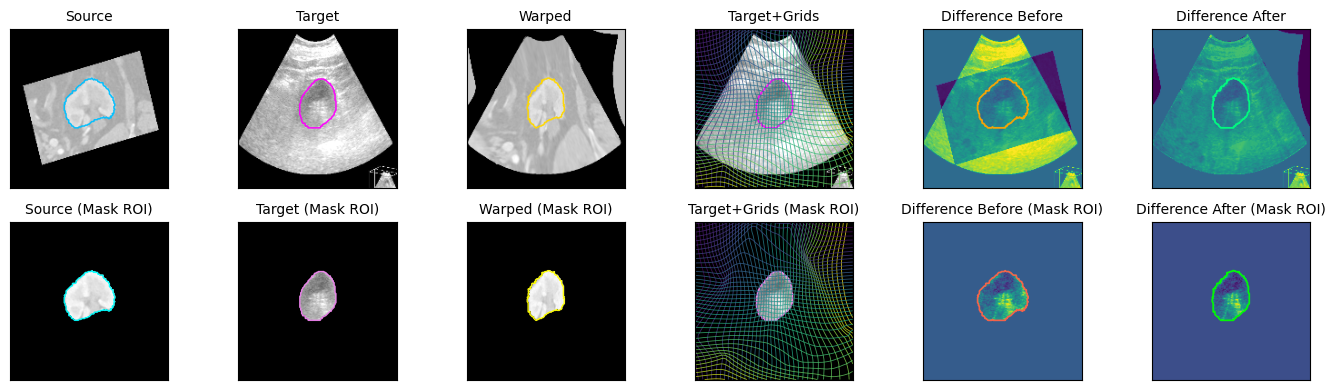

[mind_with_dice] Dice improvement: 0.6947 -> 0.9473


In [17]:
def show_as_grid_contour(ax, phi_slice, linewidth=0.6, stride=6, flip=False):
    data_size = phi_slice.size()[1:]
    plot_phi = phi_slice - 0.5
    n = plot_phi.size()[-1]
    levels = np.linspace(0, n, max(2, int(n / stride)))
    ax.contour(plot_phi[1], levels, linewidths=linewidth, alpha=0.8)
    ax.contour(plot_phi[0], levels, linewidths=linewidth, alpha=0.8)
    if flip:
        ax.set_ylim([0, data_size[0]])


def overlay_mask_contour(ax, mask_2d, color="lime", linewidth=1.0, alpha=0.95):
    if np.any(mask_2d):
        ax.contour(mask_2d.astype(float), levels=[0.5], colors=color, linewidths=linewidth, alpha=alpha)


slice_idx = INPUT_SHAPE[0] // 2
origin = "upper"
font_size = 10

phi_vec = getattr(net, "phi_AB_vectorfield", None)
phi_scaled = None
if phi_vec is not None:
    phi_vec = phi_vec.detach().cpu()
    shape_t = torch.tensor(INPUT_SHAPE, dtype=torch.float32).view(1, 3, 1, 1, 1) - 1
    phi_scaled = phi_vec * shape_t

source_img = ct_tensor.cpu()[0, 0, slice_idx].numpy()
target_img = us_tensor.cpu()[0, 0, slice_idx].numpy()
warped_img = warped_ct_tensor.cpu()[0, 0, slice_idx].numpy()
diff_before = target_img - source_img
diff_after = target_img - warped_img

ct_mask = ct_seg_tensor.cpu()[0, 0, slice_idx].numpy() > 0.5
us_mask = us_seg_tensor.cpu()[0, 0, slice_idx].numpy() > 0.5
warped_mask = warped_ct_seg_tensor.cpu()[0, 0, slice_idx].numpy() > 0.5
diff_before_mask = np.logical_or(us_mask, ct_mask)
diff_after_mask = np.logical_or(us_mask, warped_mask)

row1_images = [source_img, target_img, warped_img, target_img, diff_before, diff_after]
row1_masks = [ct_mask, us_mask, warped_mask, us_mask, diff_before_mask, diff_after_mask]
row1_titles = [
    "Source",
    "Target",
    "Warped",
    "Target+Grids",
    "Difference Before",
    "Difference After",
]

row2_images = [
    source_img * ct_mask,
    target_img * us_mask,
    warped_img * warped_mask,
    target_img * us_mask,
    diff_before * diff_before_mask,
    diff_after * diff_after_mask,
]
row2_masks = row1_masks
row2_titles = [
    "Source (Mask ROI)",
    "Target (Mask ROI)",
    "Warped (Mask ROI)",
    "Target+Grids (Mask ROI)",
    "Difference Before (Mask ROI)",
    "Difference After (Mask ROI)",
]

# Distinct contour colors/widths improve readability across modalities/panels.
row1_colors = ["deepskyblue", "magenta", "gold", "magenta", "orange", "springgreen"]
row2_colors = ["cyan", "violet", "yellow", "violet", "tomato", "lime"]
row1_linewidths = [1.1, 1.1, 1.1, 1.1, 1.3, 1.3]
row2_linewidths = [1.0, 1.0, 1.0, 1.0, 1.2, 1.2]

fig, axes = plt.subplots(2, 6, figsize=(14, 4))

for col in range(6):
    cmap = "gray" if col < 4 else None
    axes[0, col].imshow(row1_images[col], cmap=cmap, origin=origin)
    overlay_mask_contour(
        axes[0, col],
        row1_masks[col],
        color=row1_colors[col],
        linewidth=row1_linewidths[col],
    )
    if col == 3 and phi_scaled is not None:
        show_as_grid_contour(axes[0, col], phi_scaled[0, [1, 2], slice_idx], linewidth=0.6, stride=4)
    axes[0, col].set_title(row1_titles[col], fontsize=font_size)

for col in range(6):
    cmap = "gray" if col < 4 else None
    axes[1, col].imshow(row2_images[col], cmap=cmap, origin=origin)
    overlay_mask_contour(
        axes[1, col],
        row2_masks[col],
        color=row2_colors[col],
        linewidth=row2_linewidths[col],
    )
    if col == 3 and phi_scaled is not None:
        show_as_grid_contour(axes[1, col], phi_scaled[0, [1, 2], slice_idx], linewidth=0.6, stride=4)
    axes[1, col].set_title(row2_titles[col], fontsize=font_size)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"[{selected_setup_label}] Dice improvement: {dice_before:.4f} -> {dice_after:.4f}")